# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 41     |  |
| :-------------|:-------------|
| Floor van de Schaft | 6246648 |
| Bruno Schouten | 6577423 |
| Job Kruisdijk | 6278108 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Floor', 'Bruno','Job']

## Opdracht 1: Planning.

| Planning Groep: 41     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren  | 11:15- 12:00 |
| Testen meetopstelling | 12:00 - 12:30 |
| Eerste iteratie| 13:30 - 14:30 |
| Tweede iteratie en eindalgoritme | 14:30 - 16:00 |
| Testen eindalgoritme | 16:00 - 16:30 |
| Opruimen en inleveren | 16:30 - 17:30 |
| groep aanwezig 1| 10:45 - 12:30 |
| groep aanwezig 2| 13:30 - 16:30 |
| Pauze 1| 10:30 - 10:45 |
| Pauze 2| 12:30 - 13:30 |

## Opdracht 2: Import libs.

In [2]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep 41
<img src="kalibreer.png" width="400">

a =  0.03432830410620591 b =  0.8885045331885933


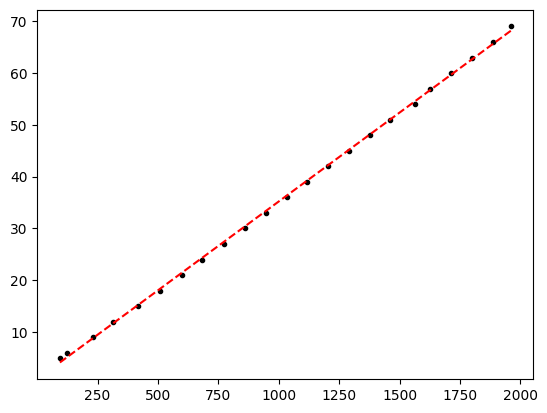

In [3]:
afstanden = np.array([5,6,9,12,15,18,21,24,27,30,33,36,39,42,45,48,51,54,57,60,63,66,69])
bits = np.array([94,124,230,314,417,510,600,683,773,858,945,1033,1118,1205,1290,1377,1460,1565,1627,1712,1800,1888,1960])

def fit(x,a,b):
    return a*x+b
popt,pcov = curve_fit(fit,bits,afstanden)
x_fit = np.linspace(min(bits),max(bits),1000)
y_fit = fit(x_fit, *popt)
plt.plot(bits,afstanden,'k.')
plt.plot(x_fit,y_fit,'r--')

print('a = ', popt[0], 'b = ', popt[1])


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  78.0
1   0  30   0  20  46.7
2  40   0  30   0  42.3
3  30   0  20   0  42.2


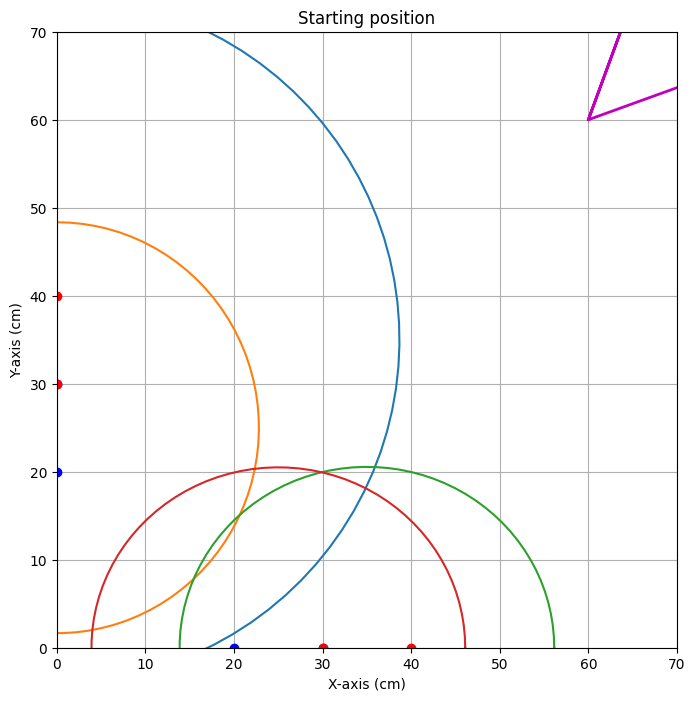


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=89.655


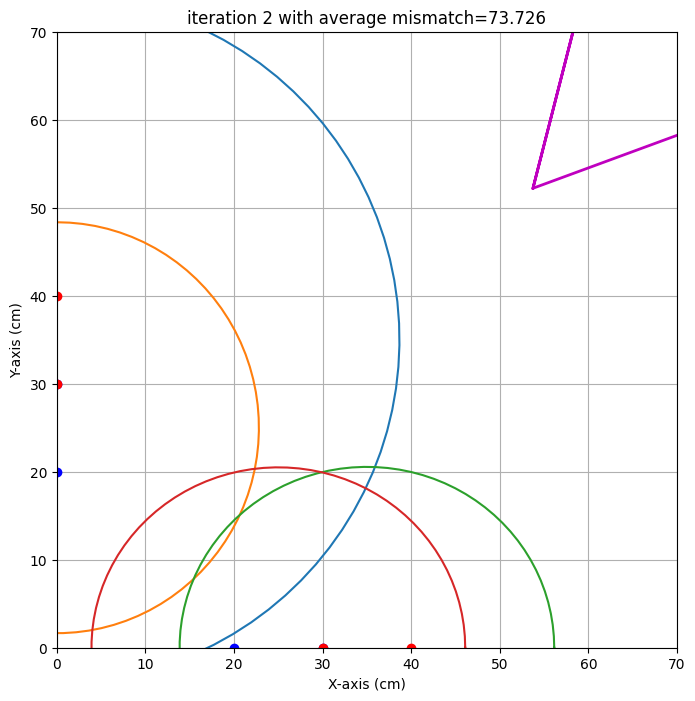

end iteration 2 with average mismatch=73.726


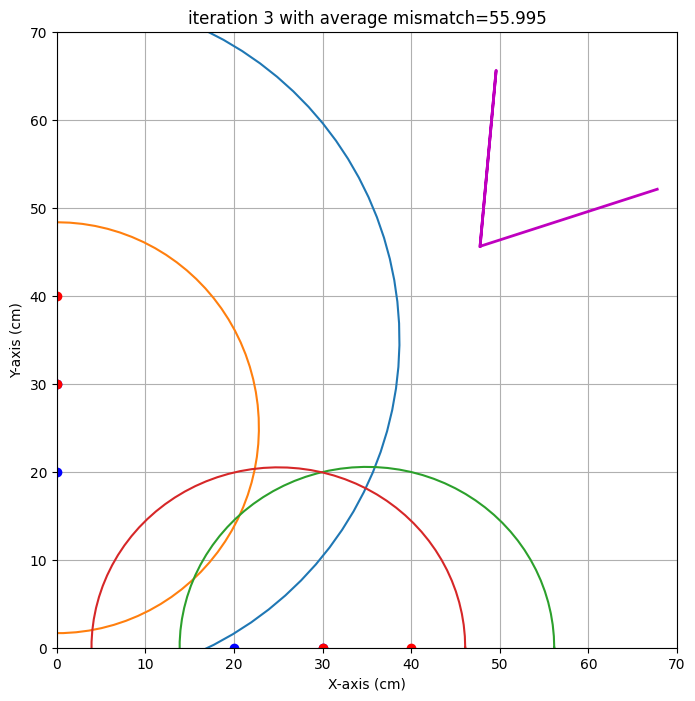

end iteration 3 with average mismatch=55.995


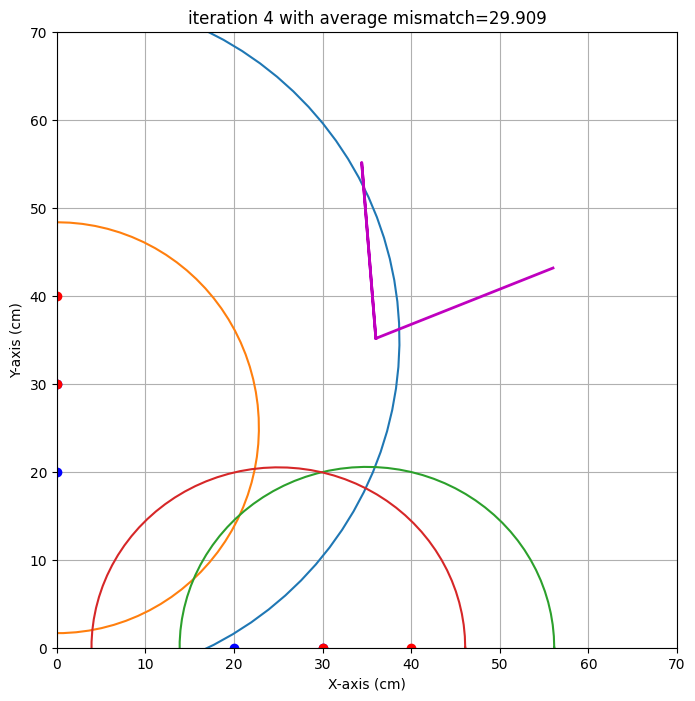

end iteration 4 with average mismatch=29.909


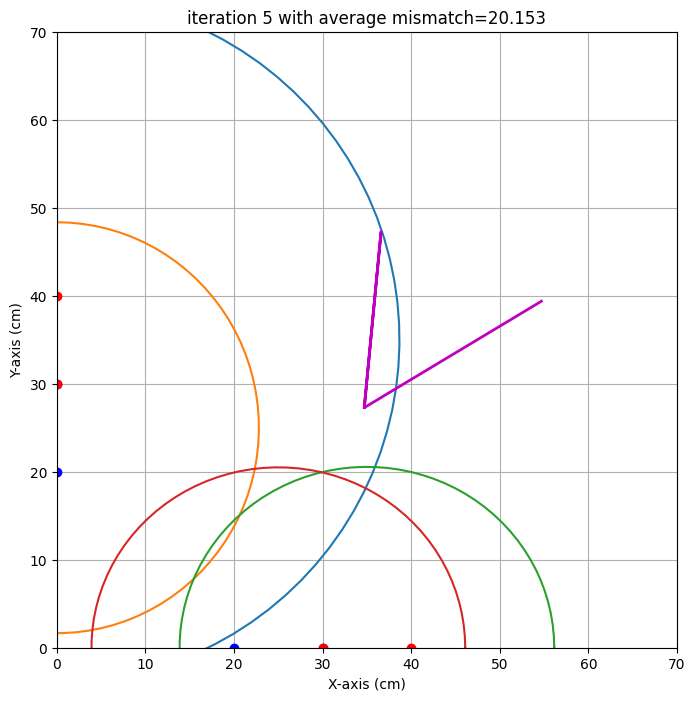

end iteration 5 with average mismatch=20.153


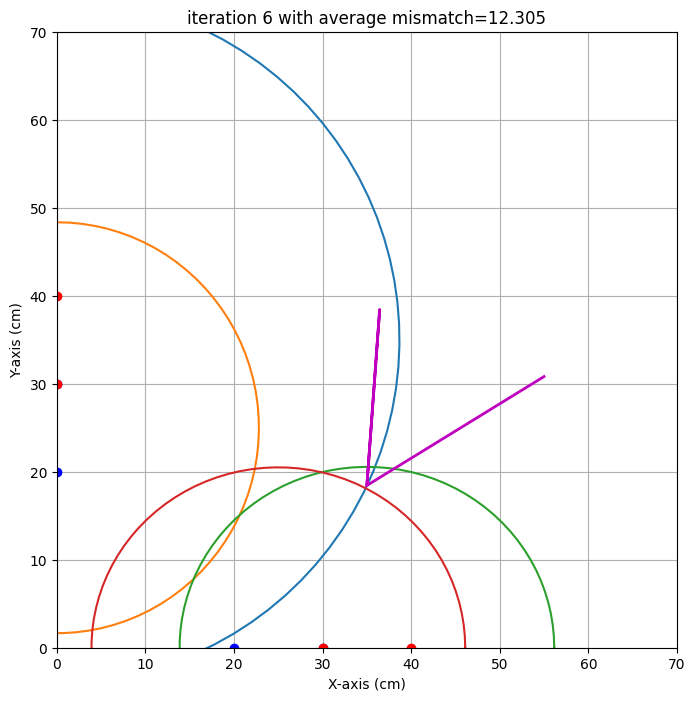

end iteration 6 with average mismatch=12.305


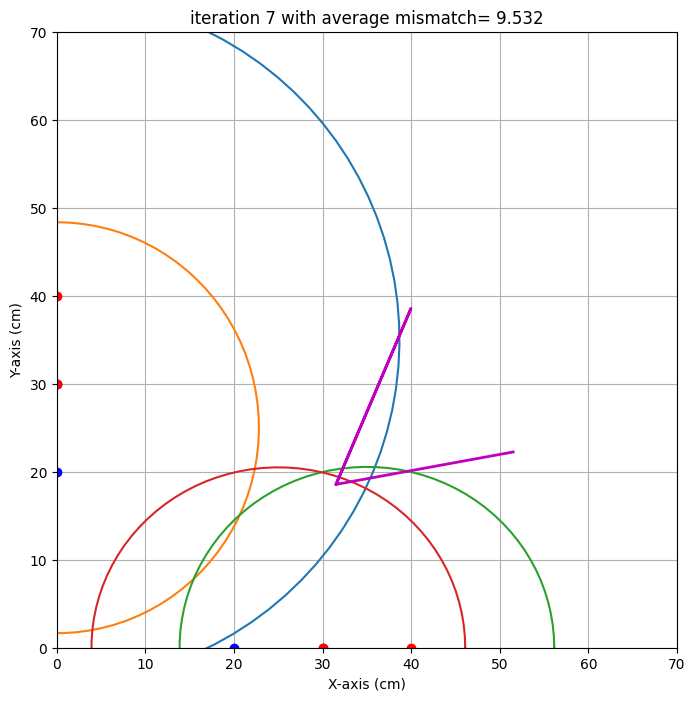

end iteration 7 with average mismatch= 9.532


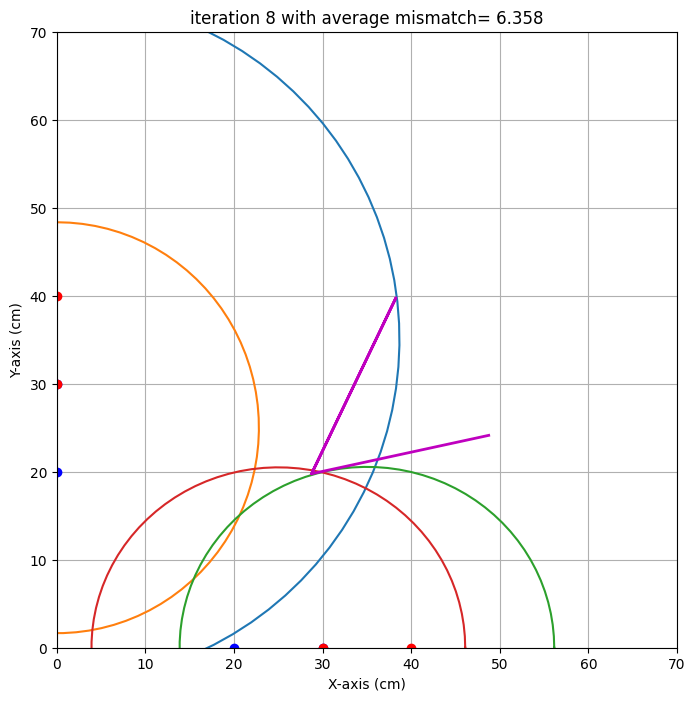

end iteration 8 with average mismatch= 6.358
end iteration 9 with average mismatch= 6.338
end iteration 10 with average mismatch= 6.336


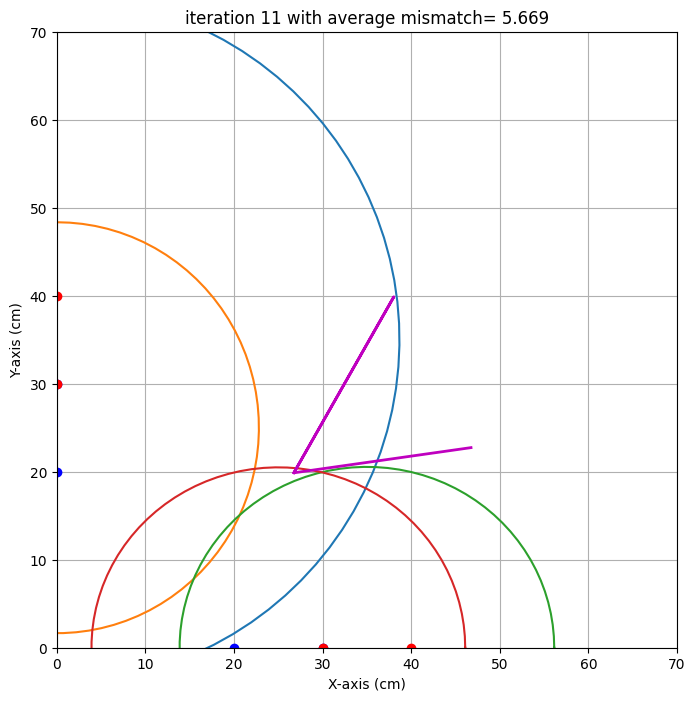

end iteration 11 with average mismatch= 5.669


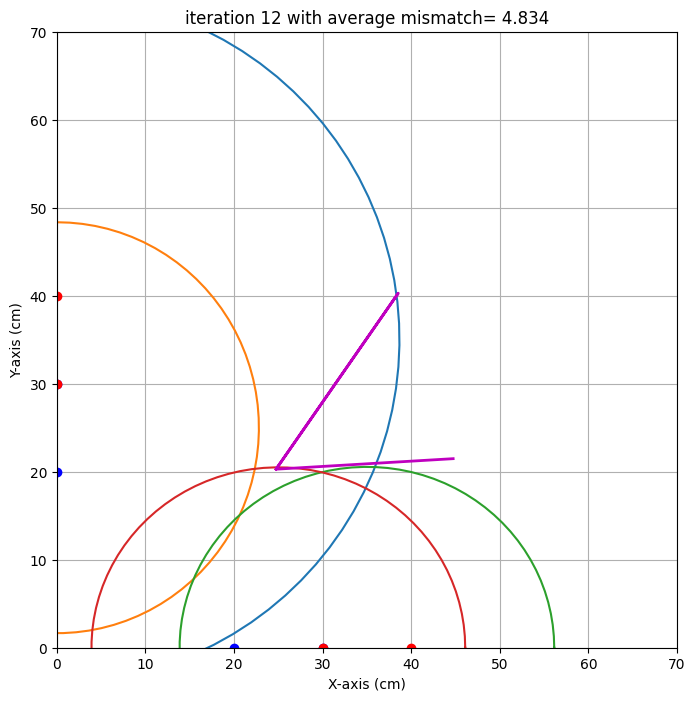

end iteration 12 with average mismatch= 4.834


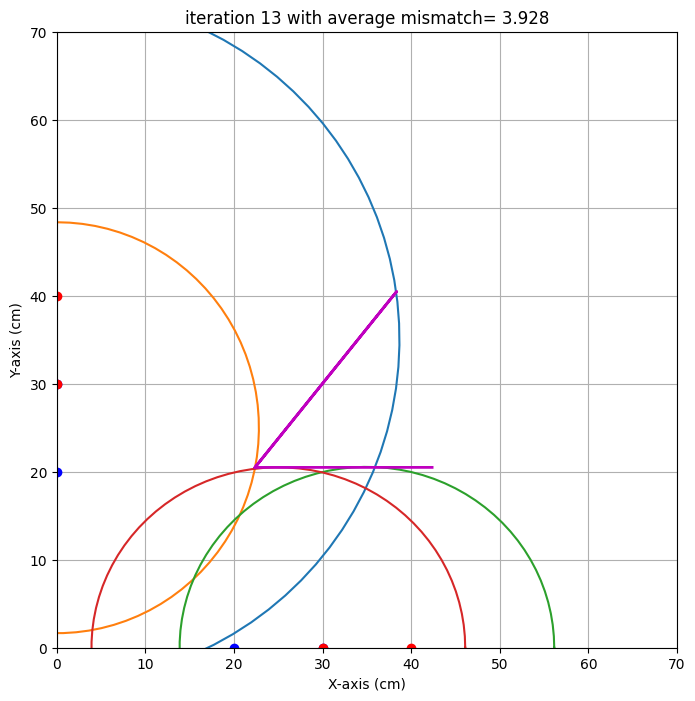

end iteration 13 with average mismatch= 3.928
end iteration 14 with average mismatch= 3.740
end iteration 15 with average mismatch= 3.720
end iteration 16 with average mismatch= 3.717
end iteration 17 with average mismatch= 3.717
end iteration 18 with average mismatch= 3.717
end iteration 19 with average mismatch= 3.717
end iteration 20 with average mismatch= 3.717
end iteration 21 with average mismatch= 3.717
end iteration 22 with average mismatch= 3.717
end iteration 23 with average mismatch= 3.717
end iteration 24 with average mismatch= 3.717
end iteration 25 with average mismatch= 3.717
end iteration 26 with average mismatch= 3.717
end iteration 27 with average mismatch= 3.717
end iteration 28 with average mismatch= 3.717
end iteration 29 with average mismatch= 3.717
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 3.717
###############################################################

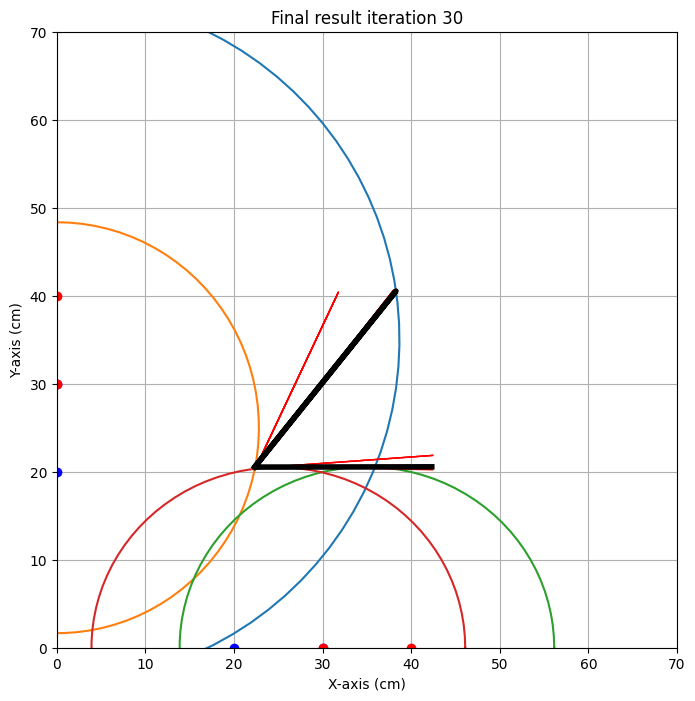

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,78.0],
    [0,30,0,20,46.7],
    #[0,10,0,20,],
    [40,0,30,0,42.3],
    [30,0,20,0,42.2],
    #[10,0,20,0,],
    #[10,0,0,10,]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 22.3 cm met een standaardafwijking van 0.1 cm 
y0: 20.5 cm met een standaardafwijking van 0.1 cm 
alpha: 0.1 graden met een standaardafwijking van 4.1 graad 
beta: 38.6 graden met een standaardafwijking van 13.5 graad 



## Opdracht 5: Iteratie 0

#### algoritme Bruno Schouten
Voeg een foto in van het algoritme van het eerste groepslid
<img src="bruno_schets.png" width="400">

#### algoritme Floor
Voeg een foto in van het algoritme van het tweede groepslid
<img src="floor_schets.png" width="400">

#### algoritme Job
Voeg een foto in van het algoritme van het derde groepslid
<img src="job_schets.png" width="400">

## Opdracht 6: Test iteratie 0.

In [6]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':40,  #zelf aanvullen,
           'y0':42,#zelf aanvullen,
           'alpha' : 5,#zelf aanvullen,
           'beta' : 5 #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Bruno' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,30,0,60,86],
    [30,0,60,0,92],
    #[20,0,40,0, ], #error meting
    [0,50,0,70, 86.12],
    [40,0,70,0,87.77] 
    ]),
       'Floor' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [60,0,70,0,83.7],
    [55,0,65,0,83.9],
    #[20,0,30,0,], #error meting
    #[0,20,0,30, 85.],
    [0,60,0,70,91.0],
    [0,45,0,55,87.2],
    ]) 
    }
       




Opmerkingen Bruno algoritme: omdat de afstand tot de y-as kleiner is dan de afstand tot de x-as. Wordt er doorgemeten op de y-as
r_y < r_x (r_x_ellips reikt dichterbij de oorsprong, de r_y_ellips worden de brandpunten gezet hoger op de y-as)
hierdoor worden de gebieden afgezet langs de y-as naar boven
de error vertelt ons dat het object zich niet dicht bij de oorsprong bevindt 
we zoeken posities zo ver mogelijk op de x-as 

## Opdracht 7: Evaluatie.

Bruno
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  30   0  60  86.00
1  30   0  60   0  92.00
2   0  50   0  70  86.12
3  40   0  70   0  87.77


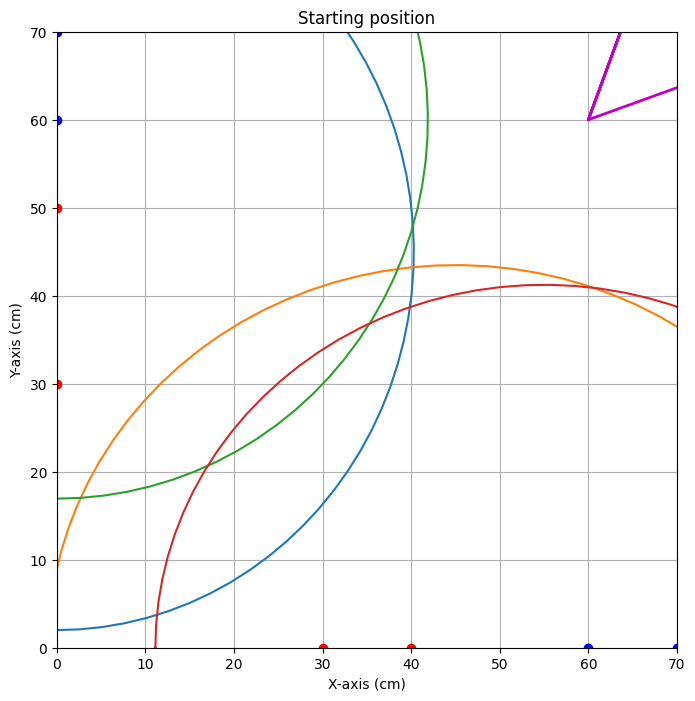


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=42.766


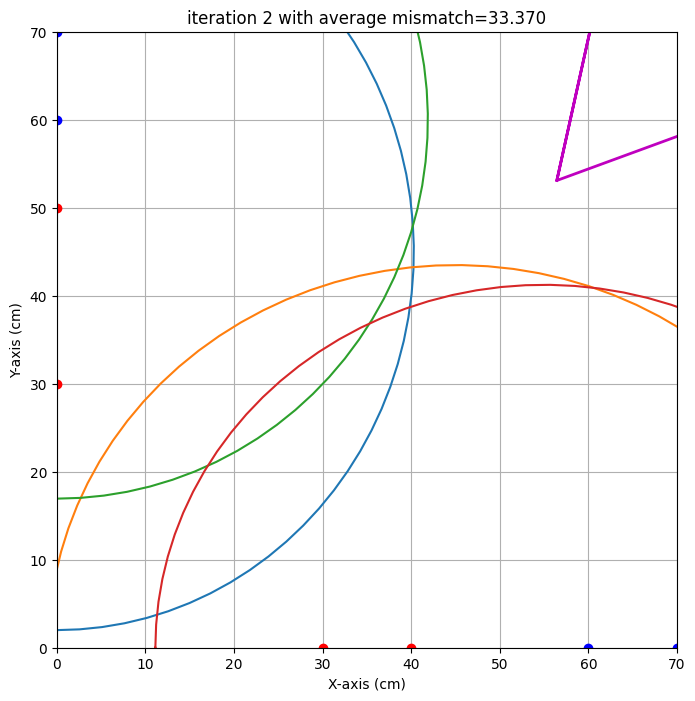

end iteration 2 with average mismatch=33.370


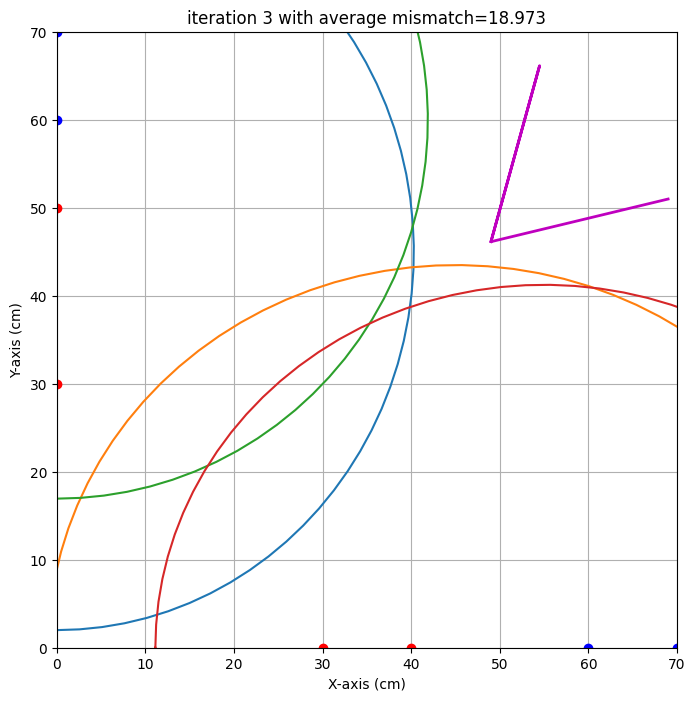

end iteration 3 with average mismatch=18.973


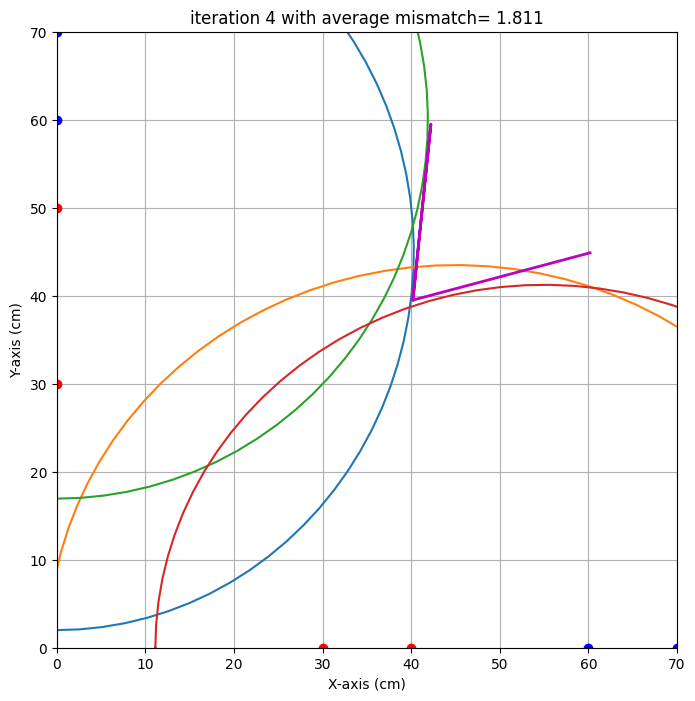

end iteration 4 with average mismatch= 1.811


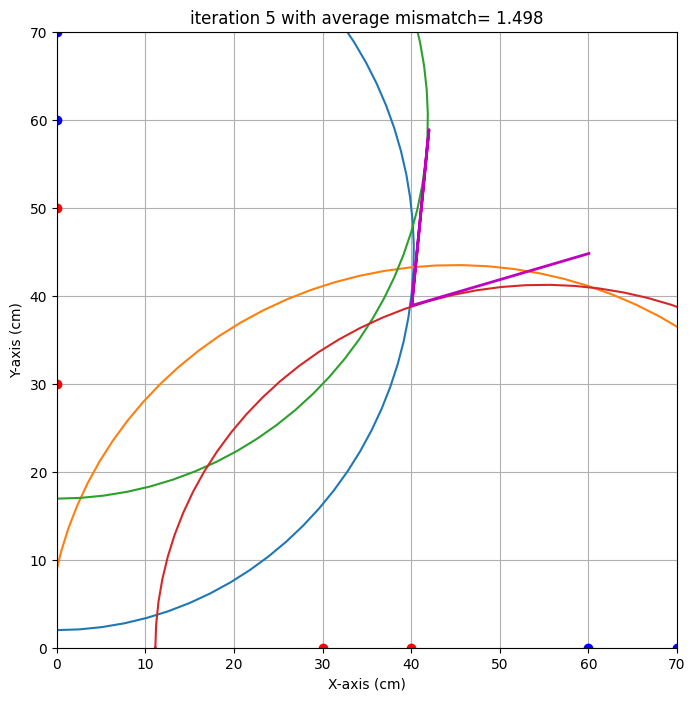

end iteration 5 with average mismatch= 1.498
end iteration 6 with average mismatch= 1.479
end iteration 7 with average mismatch= 1.475
end iteration 8 with average mismatch= 1.416
end iteration 9 with average mismatch= 1.399
end iteration 10 with average mismatch= 1.392
end iteration 11 with average mismatch= 1.392
end iteration 12 with average mismatch= 1.392
end iteration 13 with average mismatch= 1.392
end iteration 14 with average mismatch= 1.362
end iteration 15 with average mismatch= 1.324
end iteration 16 with average mismatch= 1.301
end iteration 17 with average mismatch= 1.300
end iteration 18 with average mismatch= 1.299
end iteration 19 with average mismatch= 1.299
end iteration 20 with average mismatch= 1.299
end iteration 21 with average mismatch= 1.299
end iteration 22 with average mismatch= 1.280
end iteration 23 with average mismatch= 1.280
end iteration 24 with average mismatch= 1.280
end iteration 25 with average mismatch= 1.280
end iteration 26 with average mismatch=

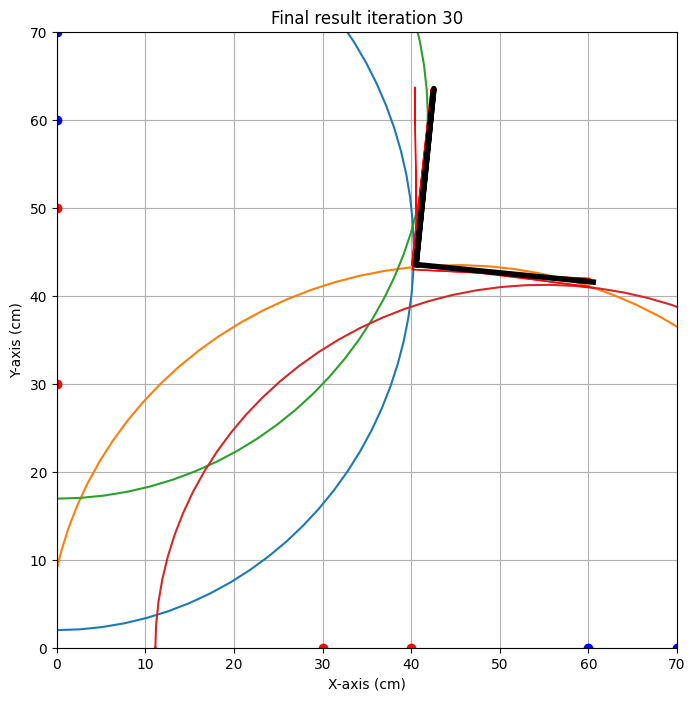

{'alpha': np.float64(-5.677548516859618), 'alpha_eps': np.float64(2.7569363193450207), 'beta': np.float64(5.72720125547003), 'beta_eps': np.float64(6.401335547859509), 'x0': np.float64(40.55393324019786), 'x0_eps': np.float64(0.47661492464438737), 'y0': np.float64(43.53947879801733), 'y0_eps': np.float64(0.5667217568657605)}
Floor
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  60   0  70   0  83.7
1  55   0  65   0  83.9
2   0  60   0  70  91.0
3   0  45   0  55  87.2


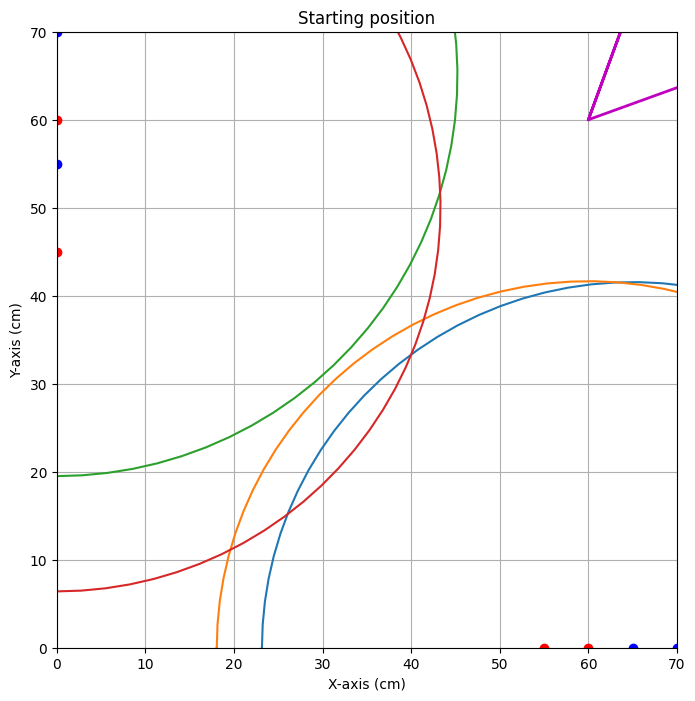


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=40.027


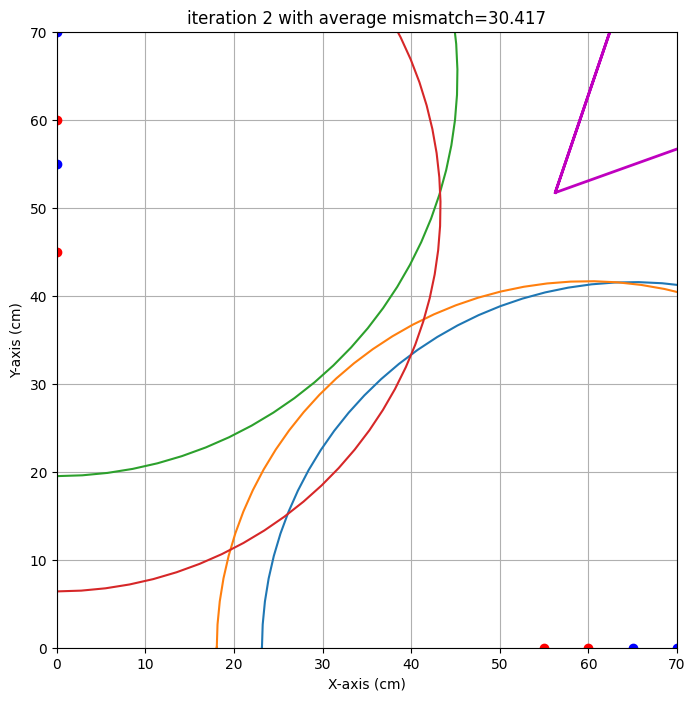

end iteration 2 with average mismatch=30.417


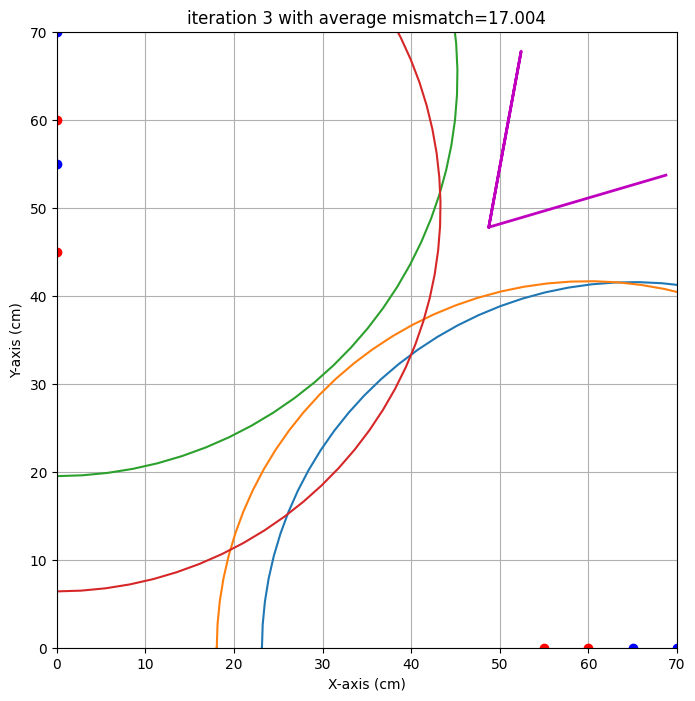

end iteration 3 with average mismatch=17.004


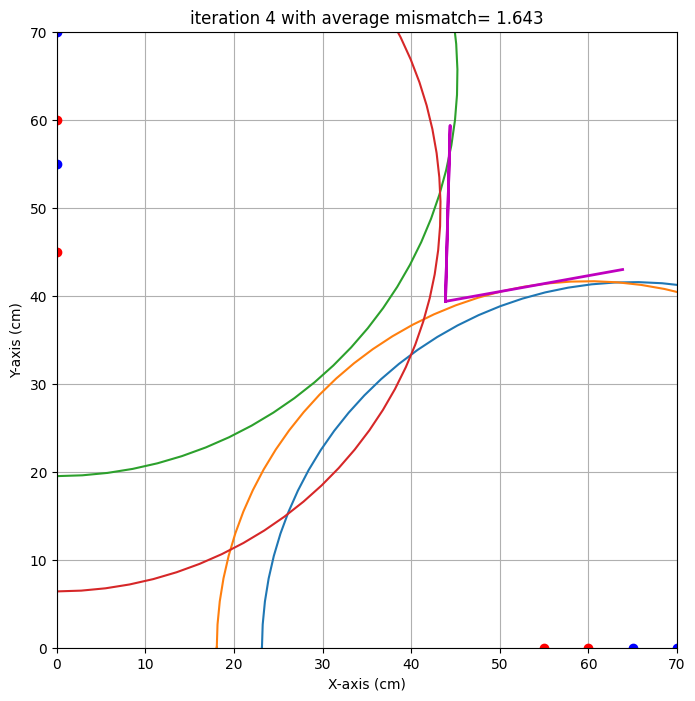

end iteration 4 with average mismatch= 1.643


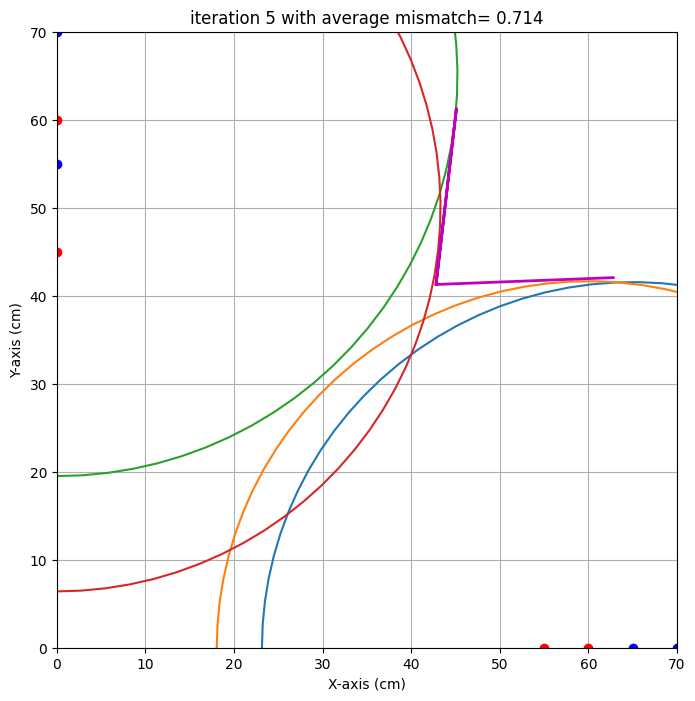

end iteration 5 with average mismatch= 0.714


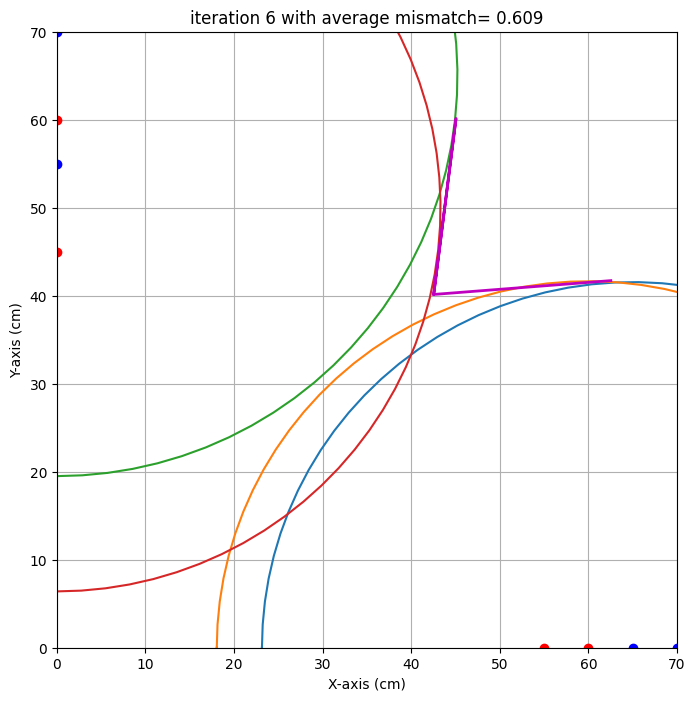

end iteration 6 with average mismatch= 0.609


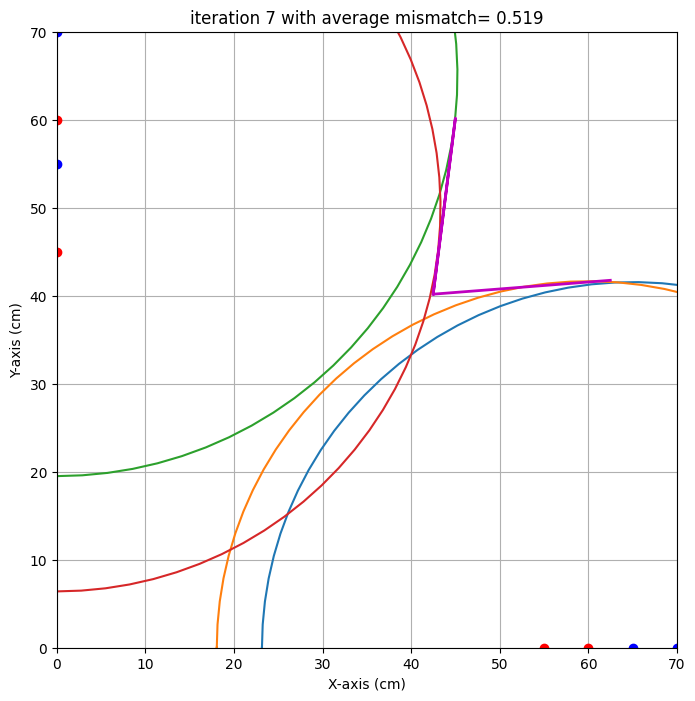

end iteration 7 with average mismatch= 0.519
end iteration 8 with average mismatch= 0.512
end iteration 9 with average mismatch= 0.512
end iteration 10 with average mismatch= 0.512


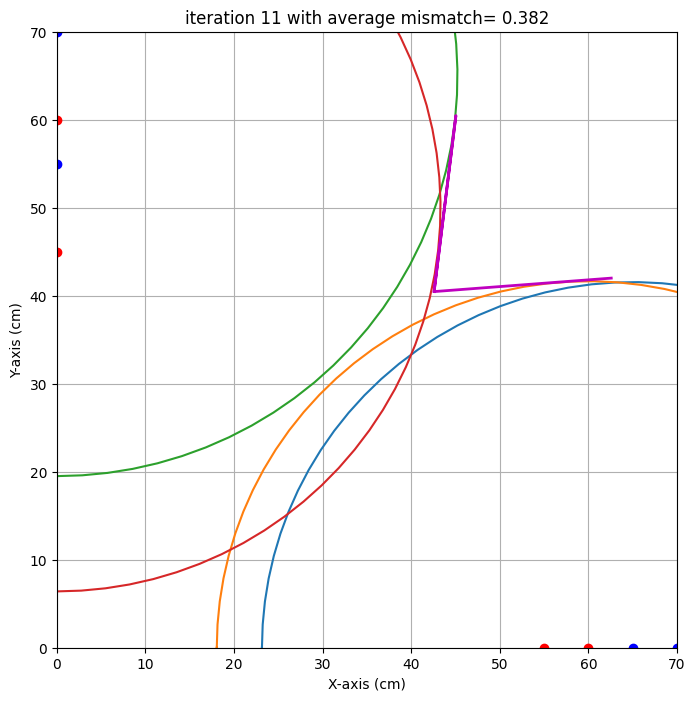

end iteration 11 with average mismatch= 0.382


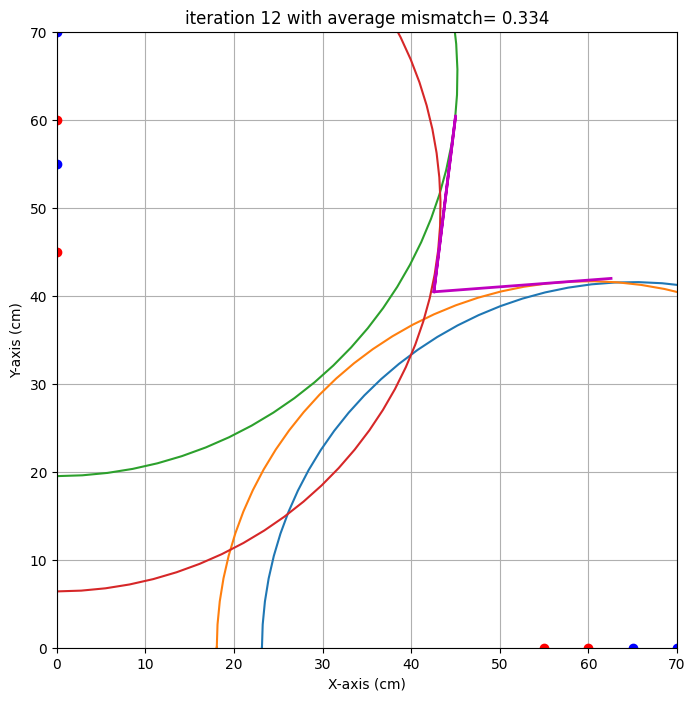

end iteration 12 with average mismatch= 0.334
end iteration 13 with average mismatch= 0.333
end iteration 14 with average mismatch= 0.333
end iteration 15 with average mismatch= 0.333
end iteration 16 with average mismatch= 0.333
end iteration 17 with average mismatch= 0.333
end iteration 18 with average mismatch= 0.333
end iteration 19 with average mismatch= 0.333
end iteration 20 with average mismatch= 0.333
end iteration 21 with average mismatch= 0.333
end iteration 22 with average mismatch= 0.333
end iteration 23 with average mismatch= 0.333
end iteration 24 with average mismatch= 0.333
end iteration 25 with average mismatch= 0.333
end iteration 26 with average mismatch= 0.333
end iteration 27 with average mismatch= 0.333
end iteration 28 with average mismatch= 0.333
end iteration 29 with average mismatch= 0.333
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.333
#################

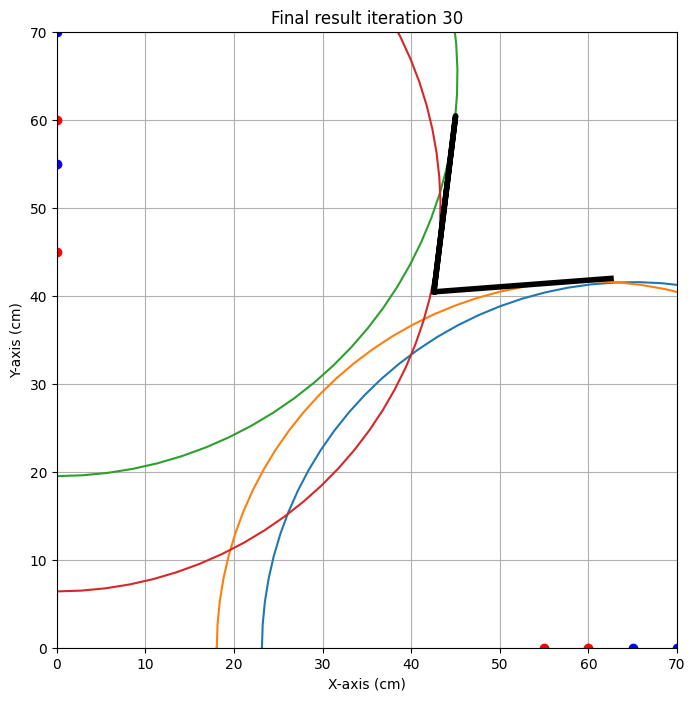

{'alpha': np.float64(4.353159780823996), 'alpha_eps': np.float64(0.06737864817100991), 'beta': np.float64(6.992600737612851), 'beta_eps': np.float64(0.847798633691272), 'x0': np.float64(42.56108817235371), 'x0_eps': np.float64(0.1369858720857451), 'y0': np.float64(40.441848199927314), 'y0_eps': np.float64(0.07843021085771085)}


In [7]:
# Hier runnen we het imaging algoritme:
resultaat = dict()
studentNames = np.array(['Bruno','Floor'])

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [8]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Bruno 
x0 target is : 40.0. Gevonden waarde: 40.6 cm met een standaardafwijking van 0.5 cm 
y0 target is : 42.0. Gevonden waarde: 43.5 cm met een standaardafwijking van 0.6 cm 
alpha target is : 5.0. Gevonden waarde: -5.7 graden met een standaardafwijking van 2.8 graad 
beta target is : 5.0. Gevonden waarde: 5.7 graden met een standaardafwijking van 6.4 graad 

Floor 
x0 target is : 40.0. Gevonden waarde: 42.6 cm met een standaardafwijking van 0.1 cm 
y0 target is : 42.0. Gevonden waarde: 40.4 cm met een standaardafwijking van 0.1 cm 
alpha target is : 5.0. Gevonden waarde: 4.4 graden met een standaardafwijking van 0.1 graad 
beta target is : 5.0. Gevonden waarde: 7.0 graden met een standaardafwijking van 0.8 graad 



## Opdracht 8: Iteratie1+.1500
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](iteratie1.png)


In [9]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  47.0
1  45   0  55   0  44.7
2  40   0  50   0  44.4
3  38   0  43   0  42.7
4   0  22   0  32  66.8
5   0  27   0  37  66.1
6   0  32   0  42  65.4


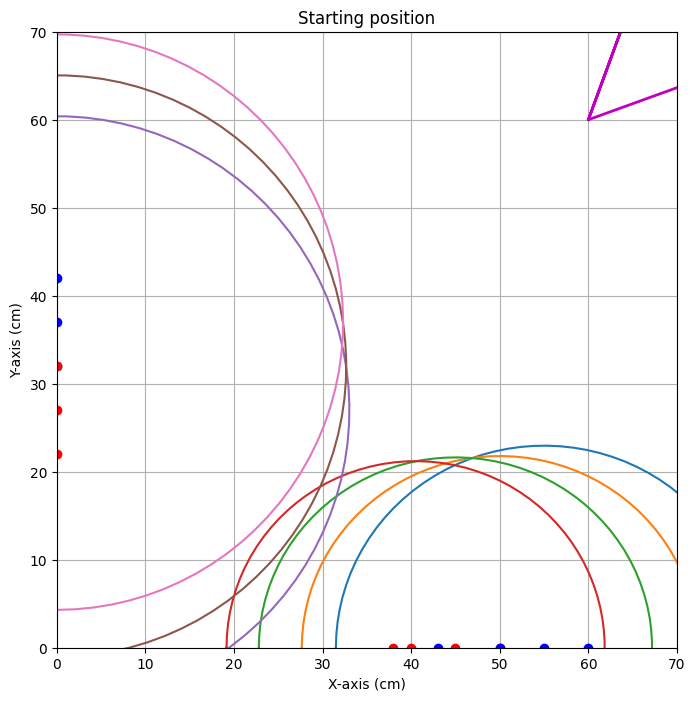


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=81.023


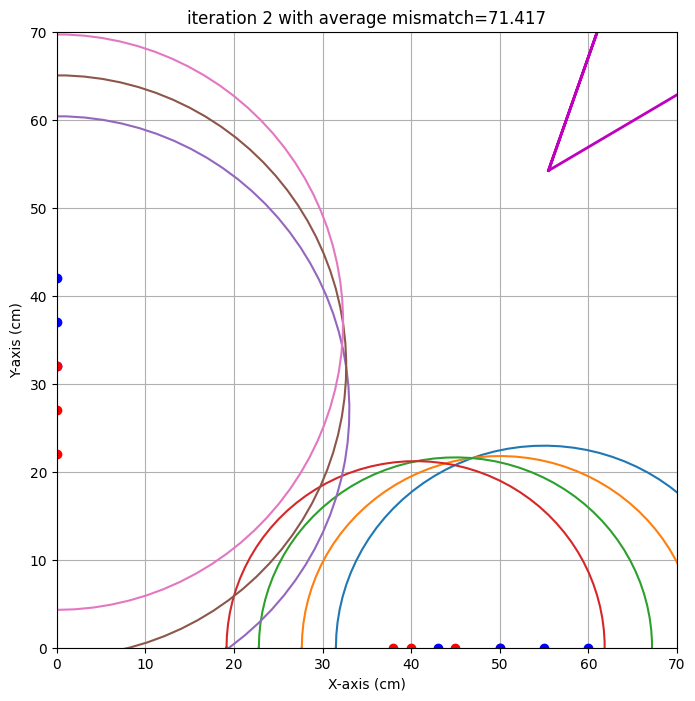

end iteration 2 with average mismatch=71.417


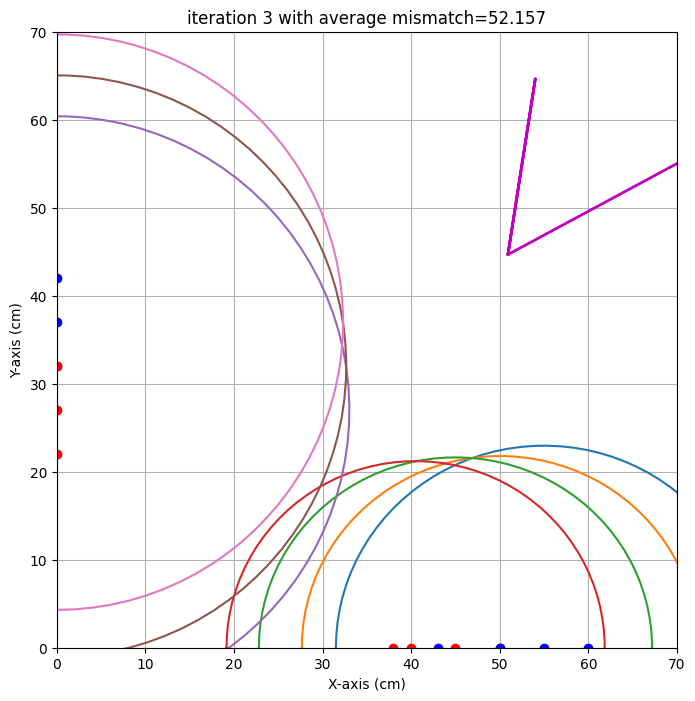

end iteration 3 with average mismatch=52.157


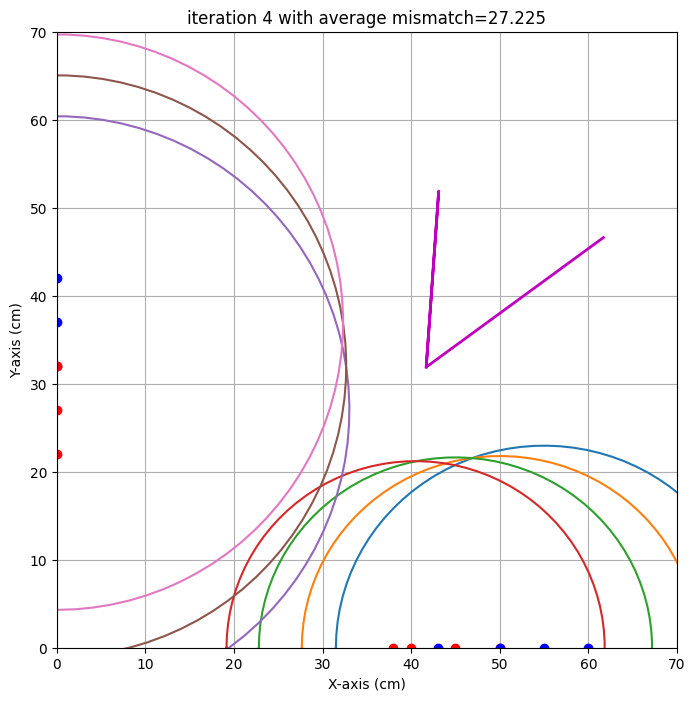

end iteration 4 with average mismatch=27.225


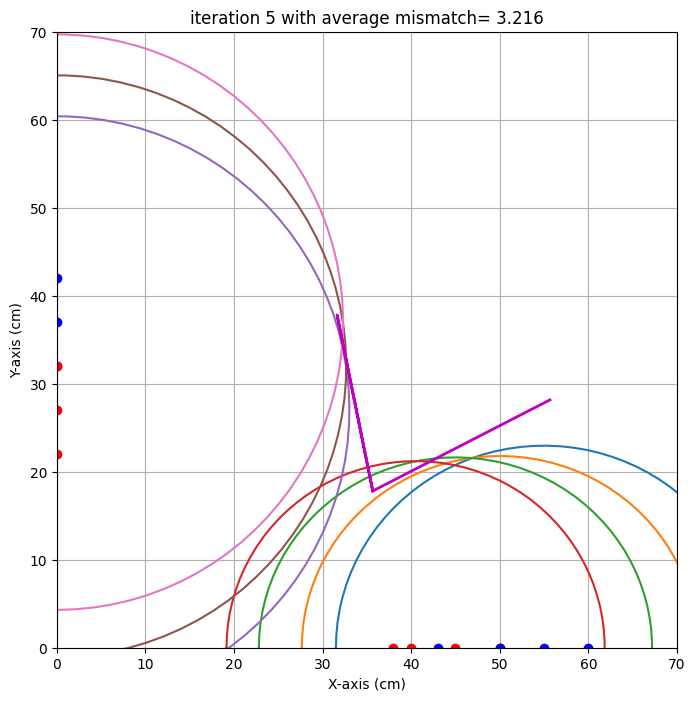

end iteration 5 with average mismatch= 3.216


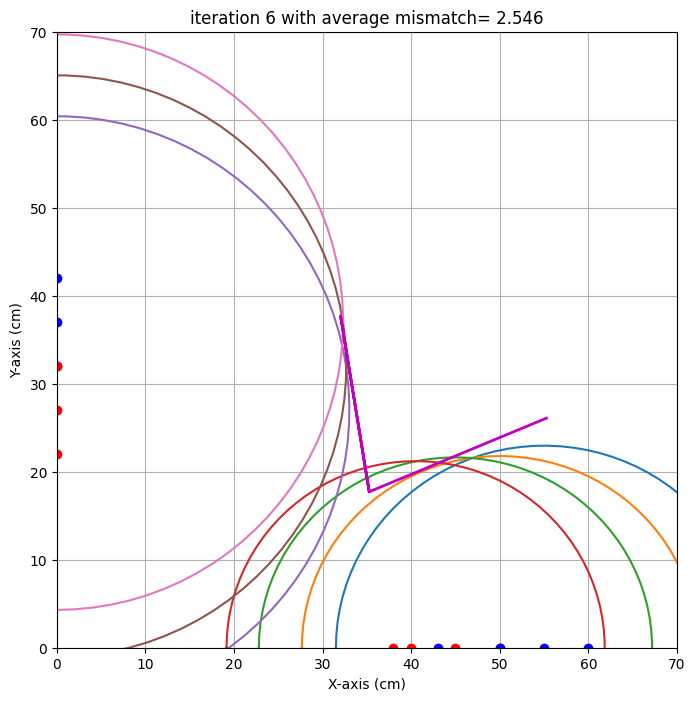

end iteration 6 with average mismatch= 2.546
end iteration 7 with average mismatch= 2.334


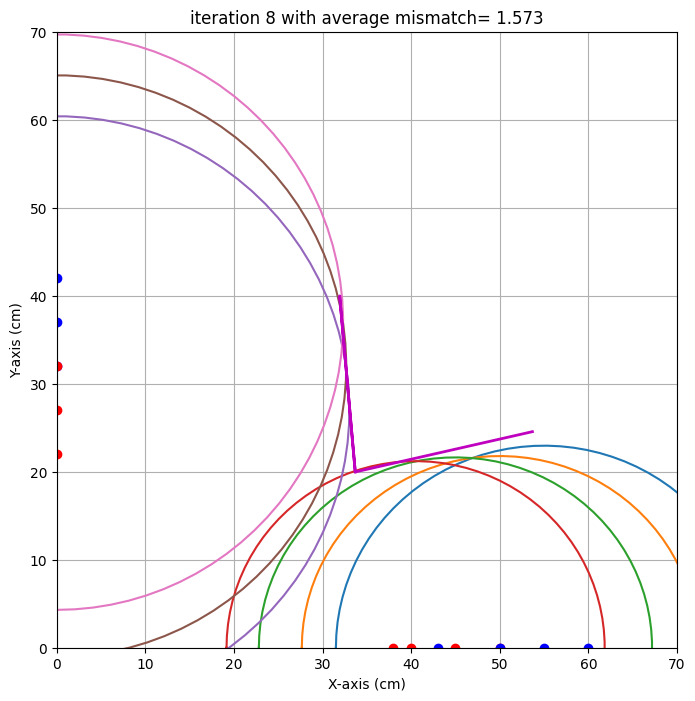

end iteration 8 with average mismatch= 1.573


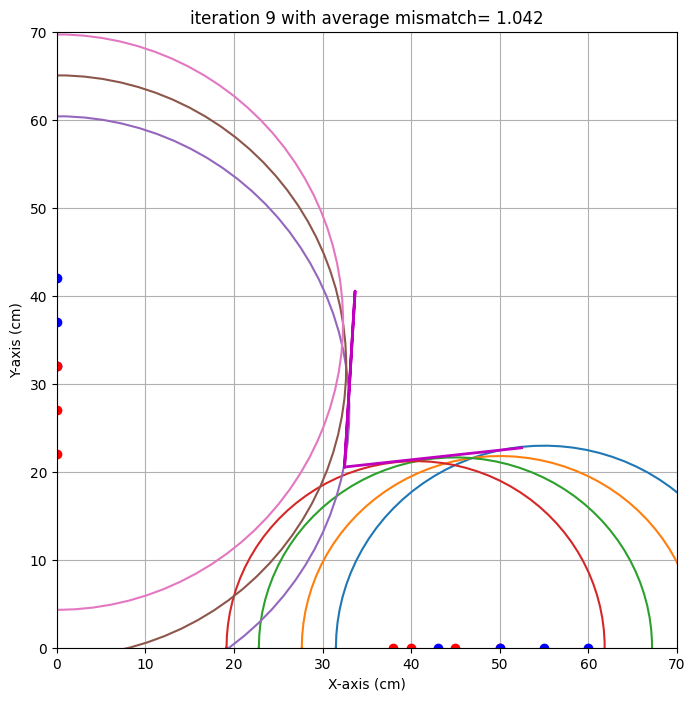

end iteration 9 with average mismatch= 1.042


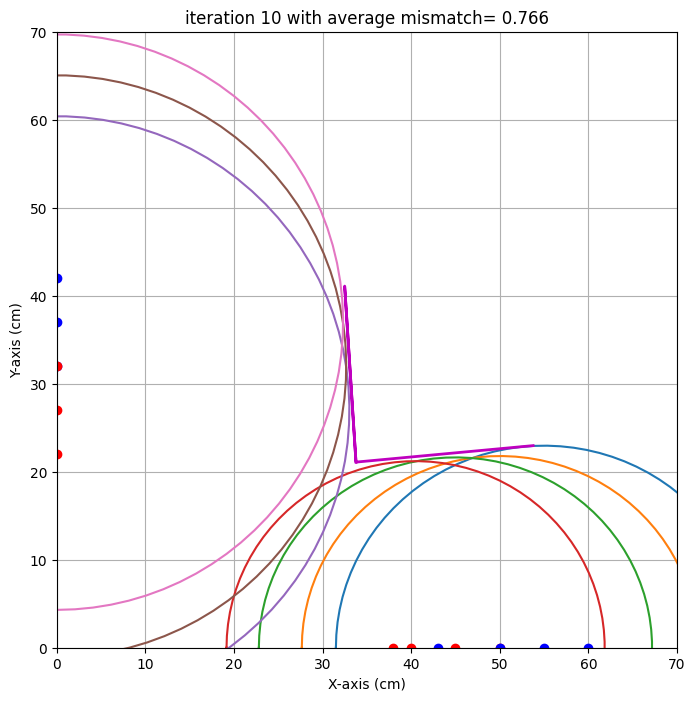

end iteration 10 with average mismatch= 0.766


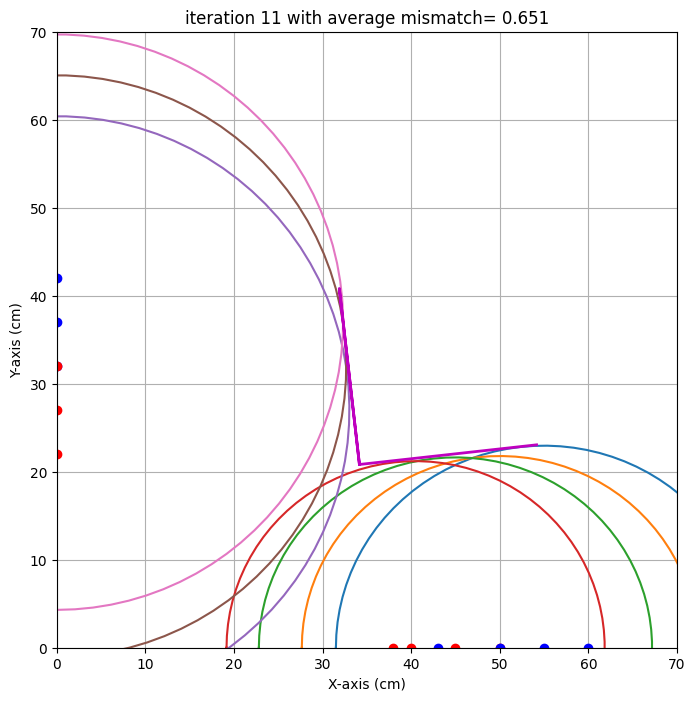

end iteration 11 with average mismatch= 0.651
end iteration 12 with average mismatch= 0.609


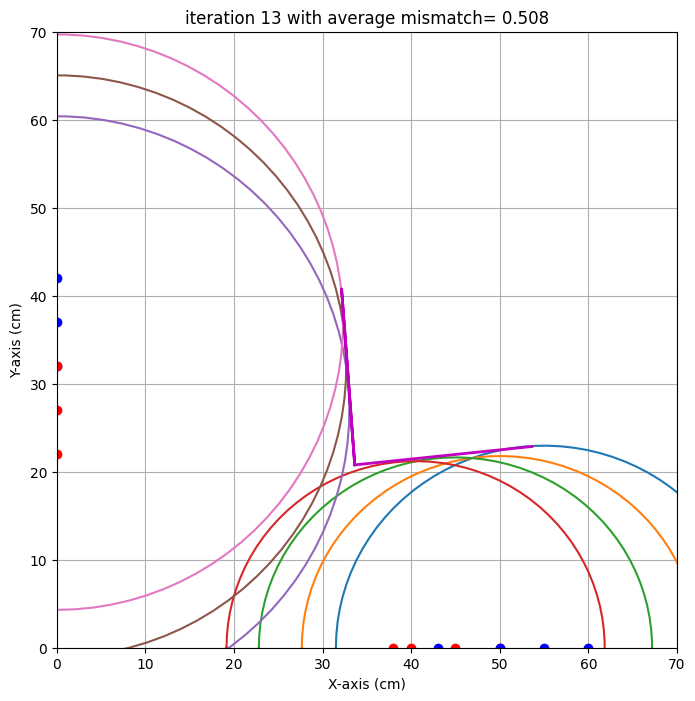

end iteration 13 with average mismatch= 0.508
end iteration 14 with average mismatch= 0.498
end iteration 15 with average mismatch= 0.478
end iteration 16 with average mismatch= 0.478
end iteration 17 with average mismatch= 0.478


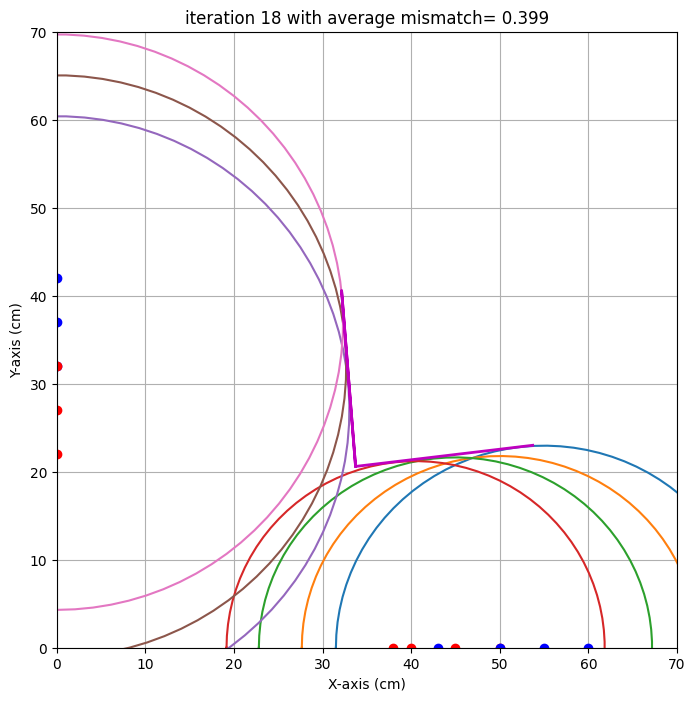

end iteration 18 with average mismatch= 0.399
end iteration 19 with average mismatch= 0.386
end iteration 20 with average mismatch= 0.382
end iteration 21 with average mismatch= 0.379
end iteration 22 with average mismatch= 0.378
end iteration 23 with average mismatch= 0.378
end iteration 24 with average mismatch= 0.378
end iteration 25 with average mismatch= 0.378
end iteration 26 with average mismatch= 0.378
end iteration 27 with average mismatch= 0.378
end iteration 28 with average mismatch= 0.378
end iteration 29 with average mismatch= 0.378
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.378
###############################################################################
end of iteration  30
Best alpha=   6.84 with uncertainty=   1.94
Best beta =  -4.53 with uncertainty=   5.01
Best x0   =  33.71 with uncertainty=   0.62
Best y0   =  20.58 with uncertainty=   0.12
################

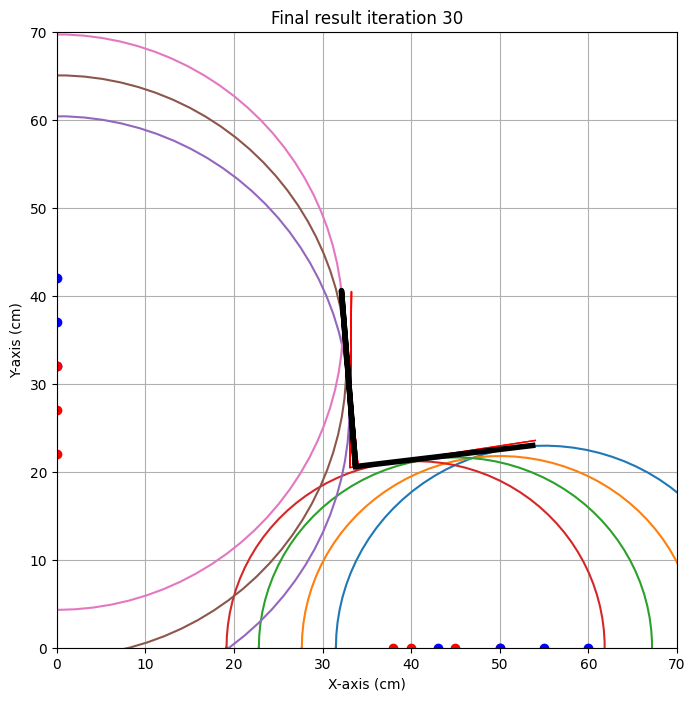

{'alpha': np.float64(6.844281712998426), 'alpha_eps': np.float64(1.9365567502960799), 'beta': np.float64(-4.530815720688497), 'beta_eps': np.float64(5.007817378576722), 'x0': np.float64(33.71286927178639), 'x0_eps': np.float64(0.6210087156634998), 'y0': np.float64(20.58383537914326), 'y0_eps': np.float64(0.11893286661435809)}
locatie 1 
x0 target is : 34.2. Gevonden waarde: 33.7 cm met een standaardafwijking van 0.6 cm 
y0 target is : 21.1. Gevonden waarde: 20.6 cm met een standaardafwijking van 0.1 cm 
alpha target is : 3.1. Gevonden waarde: 6.8 graden met een standaardafwijking van 1.9 graad 
beta target is : -4.8. Gevonden waarde: -4.5 graden met een standaardafwijking van 5.0 graad 



In [10]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':34.2,#zelf aanvullen,
                    'y0':21.1,#zelf aanvullen,
                    'alpha' :3.1, #zelf aanvullen,
                    'beta' :-4.8 #zelf aanvullen},         
}}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [50, 0, 60, 0,47.0 ],
                    [45,0,55,0,44.7],
                    [40,0,50,0,44.4],
                    [38,0,43,0,42.70],
                    [0,22,0,32,66.8],
                    [0,27,0,37,66.1],
                    [0,32,0,42,65.4]
    ])
       
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
     xs  ys  xr  yr      R
0  50.0   0  55   0  42.34
1  45.0   0  50   0  43.48
2  40.5   0  45   0  43.69
3   0.0  21   0  31  65.02
4   0.0  26   0  32  63.89
5   0.0  31   0  37  62.96


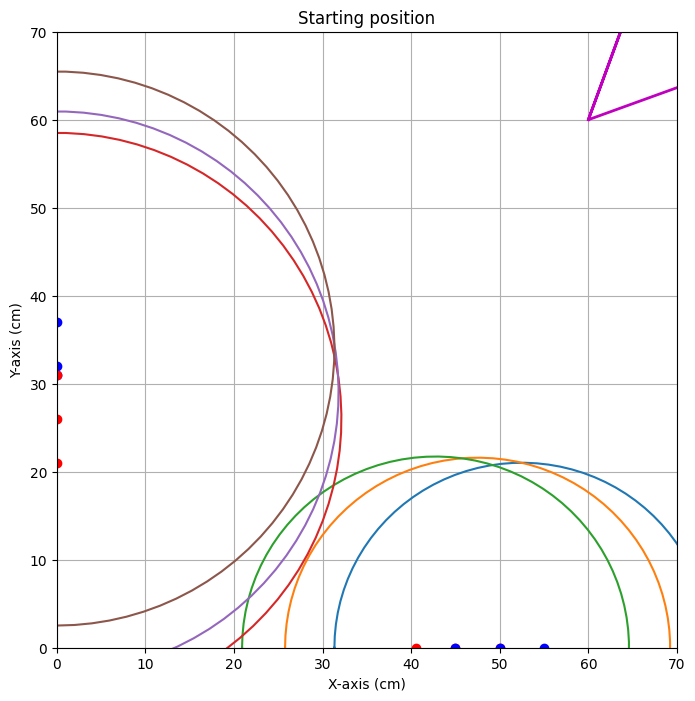


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=82.617


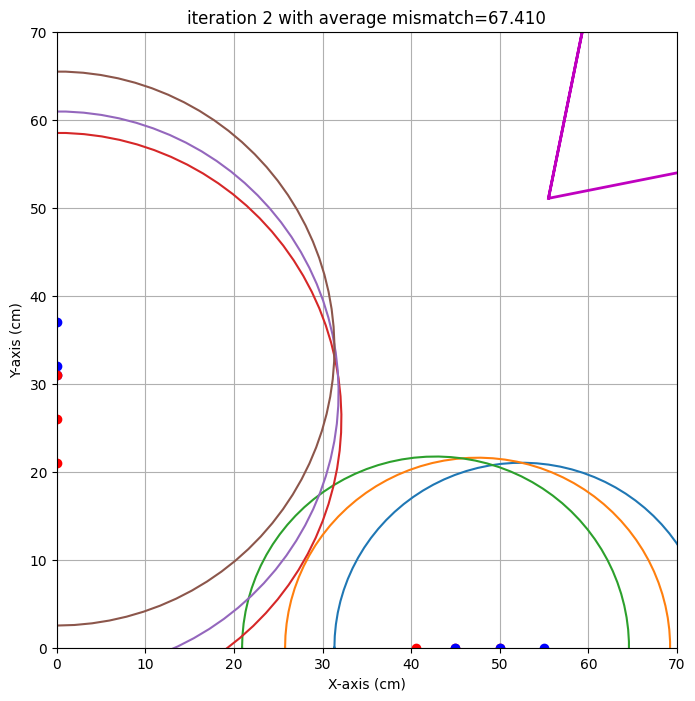

end iteration 2 with average mismatch=67.410


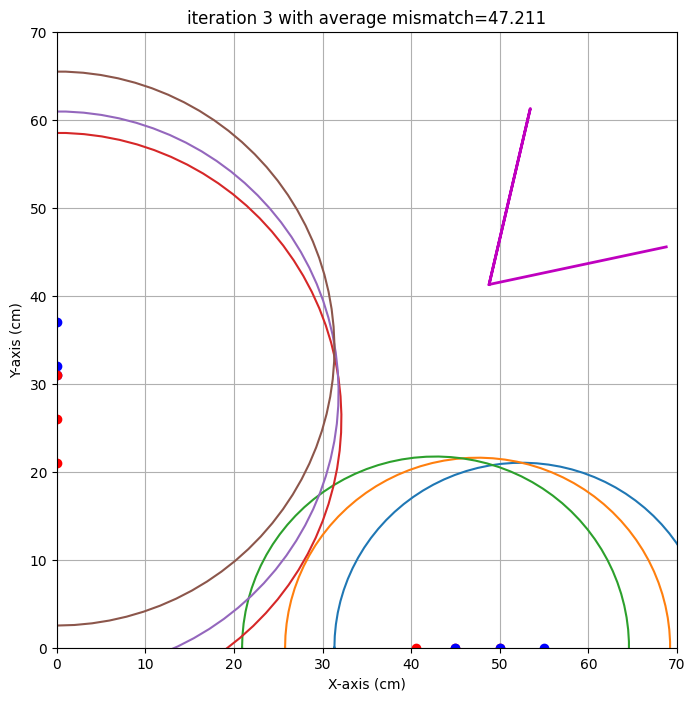

end iteration 3 with average mismatch=47.211


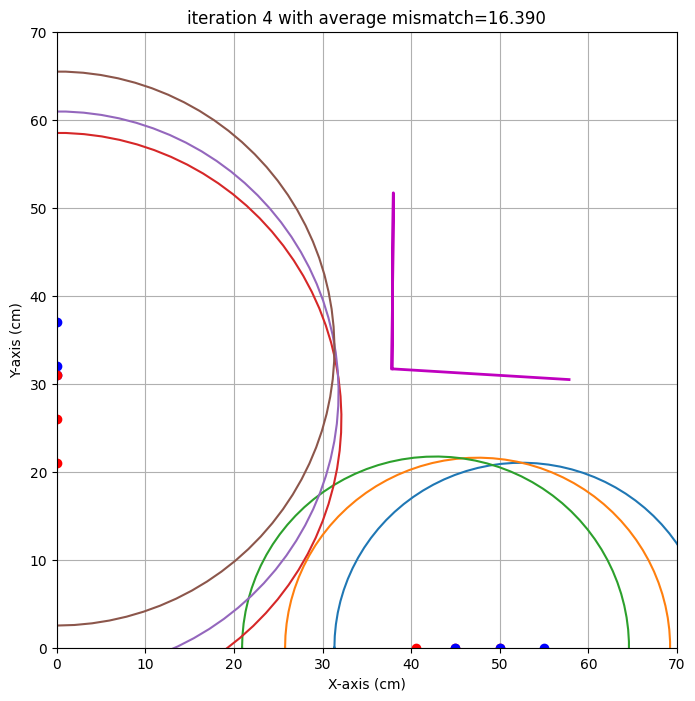

end iteration 4 with average mismatch=16.390


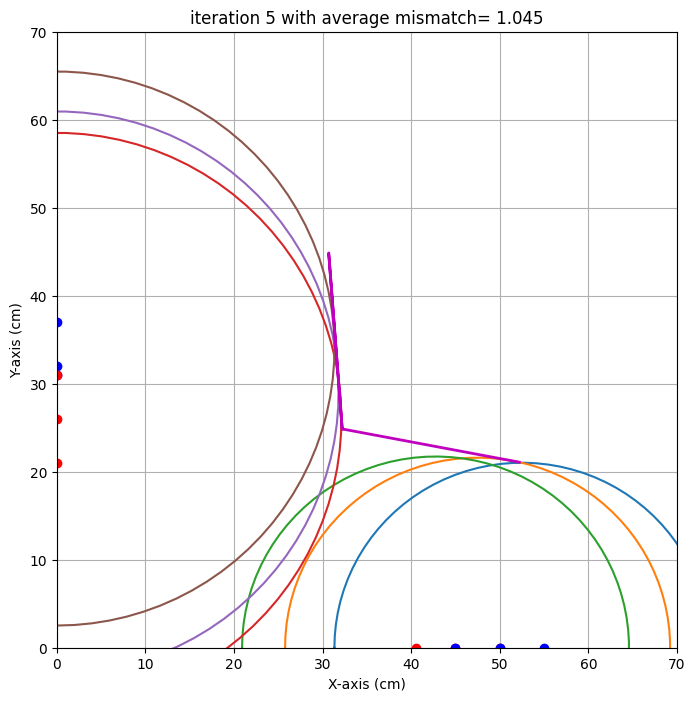

end iteration 5 with average mismatch= 1.045
end iteration 6 with average mismatch= 0.957
end iteration 7 with average mismatch= 0.888
end iteration 8 with average mismatch= 0.854
end iteration 9 with average mismatch= 0.813
end iteration 10 with average mismatch= 0.813
end iteration 11 with average mismatch= 0.806
end iteration 12 with average mismatch= 0.784


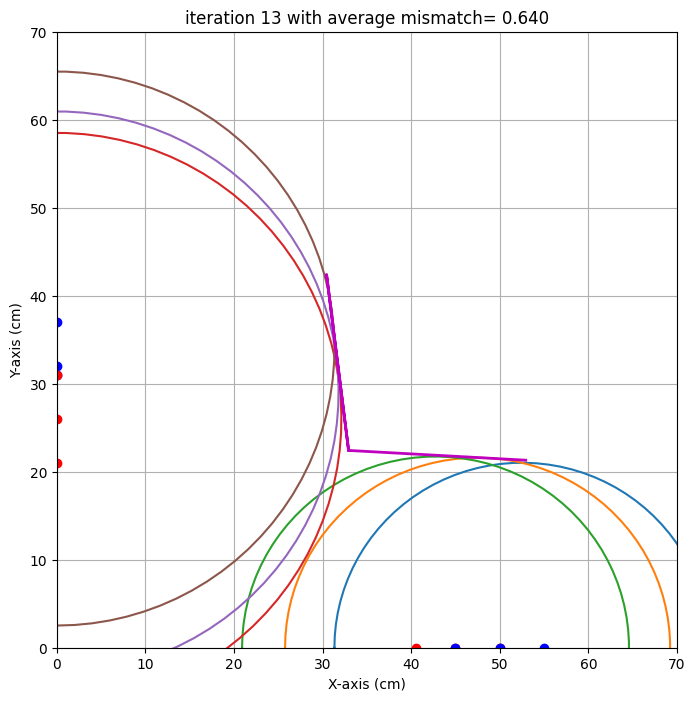

end iteration 13 with average mismatch= 0.640


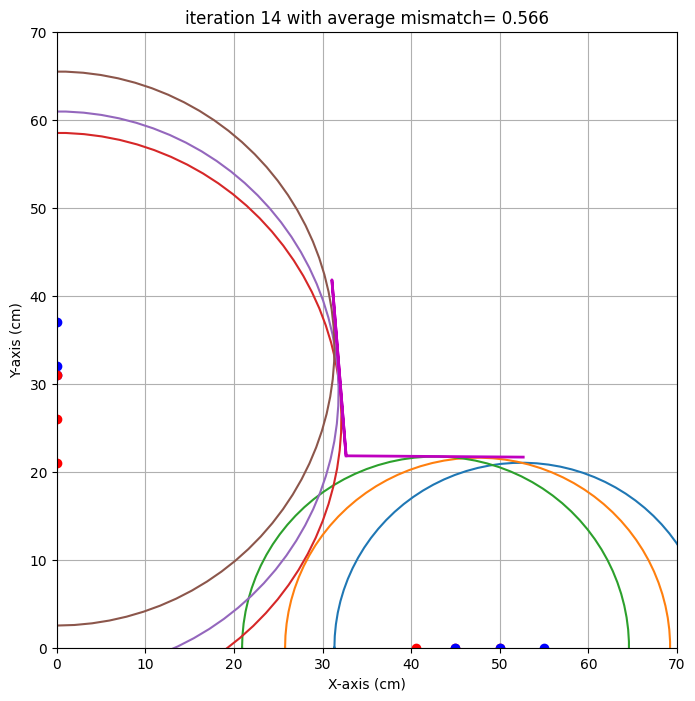

end iteration 14 with average mismatch= 0.566
end iteration 15 with average mismatch= 0.555
end iteration 16 with average mismatch= 0.551
end iteration 17 with average mismatch= 0.528
end iteration 18 with average mismatch= 0.526


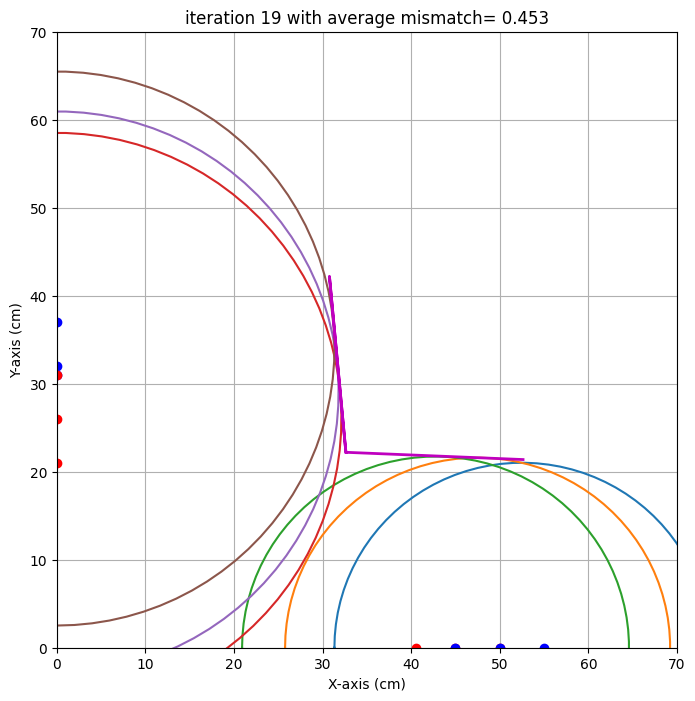

end iteration 19 with average mismatch= 0.453
end iteration 20 with average mismatch= 0.450
end iteration 21 with average mismatch= 0.448
end iteration 22 with average mismatch= 0.448
end iteration 23 with average mismatch= 0.447
end iteration 24 with average mismatch= 0.447
end iteration 25 with average mismatch= 0.442
end iteration 26 with average mismatch= 0.428
end iteration 27 with average mismatch= 0.425
end iteration 28 with average mismatch= 0.423
end iteration 29 with average mismatch= 0.422
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.422
###############################################################################
end of iteration  30
Best alpha=  -1.93 with uncertainty=   5.30
Best beta =  -5.84 with uncertainty=   2.17
Best x0   =  32.74 with uncertainty=   0.60
Best y0   =  22.08 with uncertainty=   1.54
##############################################################

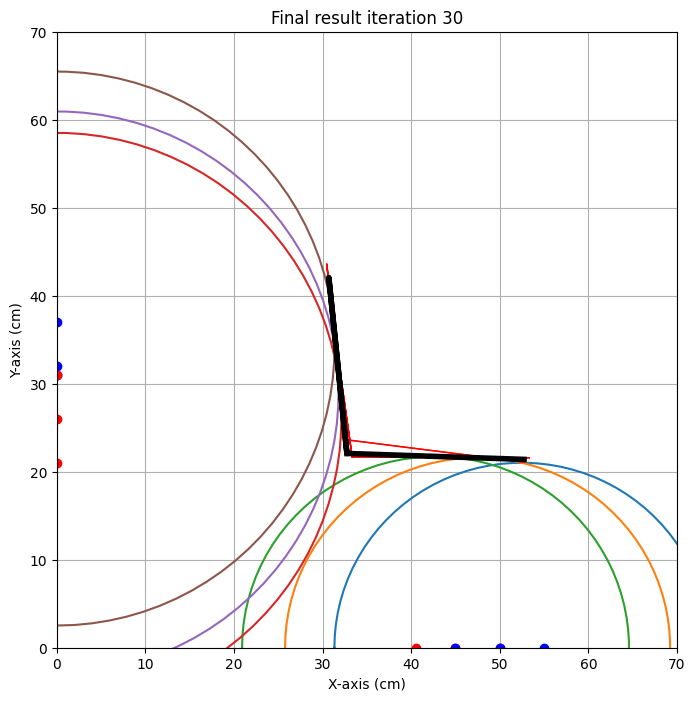

{'alpha': np.float64(-1.9299673307616525), 'alpha_eps': np.float64(5.3047116300128865), 'beta': np.float64(-5.835536302036732), 'beta_eps': np.float64(2.166384092569456), 'x0': np.float64(32.74356742835636), 'x0_eps': np.float64(0.5966129317843425), 'y0': np.float64(22.077040422424073), 'y0_eps': np.float64(1.5382516817800642)}
test locatie 
x0 target is : 32.2. Gevonden waarde: 32.7 cm met een standaardafwijking van 0.6 cm 
y0 target is : 22.0. Gevonden waarde: 22.1 cm met een standaardafwijking van 1.5 cm 
alpha target is : -4.4. Gevonden waarde: -1.9 graden met een standaardafwijking van 5.3 graad 
beta target is : -4.6. Gevonden waarde: -5.8 graden met een standaardafwijking van 2.2 graad 



In [11]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 32.2,  # zelf aanvullen,
                    'y0': 22.0, # zelf aanvullen,
                    'alpha' : -4.42,#zelf aanvullen,
                    'beta' : -4.57 #zelf aanvullen},
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    #[60, 0, 70, 0,0 ],  #error
                    [50, 0, 55, 0,42.34 ],
                    [45,0,50,0,43.48],
                    [40.5,0,45,0,43.69],
                    [0,21,0,31,65.02],
                    [0,26,0,32,63.89],
                    [0,31,0,37,62.96]


                    # zelf aanvullen
                    ])
                }






# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](1.png "Title")
Alle mogelijke opties proberen, ver weg in de as en dichtbij. Alle metingen gingen tegelijk, dit maakte het algoritme erg ingewikkeld en niet bruikbaar. Hierdoor gingen we door naar de volgende:

Figuur: ![Alt](2.png "Title")
Hier probeerden we de grootste delen van de as te vinden, en te kijken bij welke as het object dichterbij was. Het werkte wel beter, maar het idee om alleen eerst op 1 as te werken werd geboren. Want op 2 assen telkens zoeken bleek ingewikkeld

Figuur: ![Alt](3.png "Title")
Hierbij begonnen we op 1 as elke positie af te gaan, waardoor we na maximaal 5 pogingen een hit hadden. Na deze hit zou het vlak bepalen op de andere as maar 2 hits kosten. 

Conclusie:
Door de fouten en goede eigenschappen van de vorige algoritme is de 3e/laatste algorimte in staat de positie en hoek van een bepaald object te benaderen.